# Foci Detection Pipeline — Costes Lab

Detects DNA damage foci (γH2AX, 53BP1, etc.) in 2D or 3D fluorescence microscopy images.

**Method:** À trous wavelet transform (Costes & Chen, LBNL) — classical, no AI, works at any image size.

**Output per run:**
- `nuc_summary_DATE.txt` — one row per nucleus (area, P2A, n_foci, intensities, cell cycle)
- `foci_summary_DATE.txt` — one row per focus (intensity, size, location)
- `[image]_[NucID]_DAPI_spot_check.jpg` — per-nucleus overlay with foci contours

**Works on:** Google Colab and local Ubuntu/Mac/Windows (WSL) without code changes.

---
## CELL 1 — Environment, repo clone & data setup

Run this first. It detects Colab vs local, clones the CostesLab repo (Colab only),
and downloads the public test data from GitHub if not already present.

**On Colab:** requires `GITHUB_TOKEN` in Colab Secrets (🔑 icon in left sidebar).
Test data downloads automatically — no Google Drive needed.

**On local WSL:** test data clones into `~/CostesLab_TestData` automatically.
Your own data projects in `~/Documents` are also listed.

In [7]:
import os, sys
from pathlib import Path

# ── Environment detection ──────────────────────────────────────────────────
IS_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    # ── Clone CostesLab repo (private — needs GITHUB_TOKEN) ─────────────────
    from google.colab import userdata
    token = userdata.get('GITHUB_TOKEN')
    repo_url = f'https://{token}@github.com/svcostes/CostesLab.git'

    if not Path('/content/CostesLab').exists():
        print('Cloning CostesLab repo...')
        os.system(f'git clone --quiet {repo_url} /content/CostesLab')
    else:
        print('Updating CostesLab repo...')
        os.system('git -C /content/CostesLab pull --quiet')
    print('CostesLab repo ready')

    PROJECTS_ROOT = Path('/content/mnt/MyDrive/Colab Notebooks')
    TEST_DATA     = Path('/content/CostesLab_TestData')

else:
    # ── Local WSL/Ubuntu ─────────────────────────────────────────────────────
    PROJECTS_ROOT = Path.home() / 'Documents'
    TEST_DATA     = Path.home() / 'CostesLab_TestData'

# ── Clone test data if not present (PUBLIC repo — no token needed) ─────────
if not TEST_DATA.exists():
    print('Cloning CostesLab_TestData (public)...')
    os.system(f'git clone --quiet https://github.com/svcostes/CostesLab_TestData.git {TEST_DATA}')
    print(f'Test data ready at: {TEST_DATA}')
else:
    print(f'Test data found  : {TEST_DATA}')

# ── List available projects from Google Drive / Documents ──────────────────
print(f'\nEnvironment  : {"Colab" if IS_COLAB else "Local"}')
print(f'Projects root: {PROJECTS_ROOT}')

if PROJECTS_ROOT.exists():
    projects = sorted([p for p in PROJECTS_ROOT.iterdir()
                       if p.is_dir() or p.is_symlink()])
    print(f'\nAvailable projects ({len(projects)}):')
    for i, p in enumerate(projects):
        print(f'  [{i}] {p.name}')
else:
    projects = []
    print('No projects found — test data will be used by default')

Test data found  : /home/syc63/CostesLab_TestData

Environment  : Local
Projects root: /home/syc63/Documents

Available projects (2):
  [0] MyProject
  [1] scripts_for_github_reorg


## CELL 2 — Set data location

**This is the only cell you need to change between experiments.**

- Set `USE_TEST_DATA = True` to use the public test images from GitHub
- Set `USE_TEST_DATA = False` and `PROJECT_INDEX = N` to use your own data
- Or set `DATA_ROOT` directly to any path

Test data contains: 12 TIF images, 2-channel DAPI + 53BP1,
time course T_0min → T_240min after irradiation, 0.1625 µm/px.

In [8]:
# ── Select your data source ────────────────────────────────────────────────
PROJECT_INDEX = 0       # ← index from project list above (ignored if USE_TEST_DATA=True)
USE_TEST_DATA = True    # ← set False to use your own data from Google Drive / Documents

if USE_TEST_DATA:
    # Public test data cloned from github.com/svcostes/CostesLab_TestData
    DATA_ROOT = TEST_DATA / 'SpotDetection' / 'human_blood_53bp1'
    print(f'Using test data: {DATA_ROOT}')

elif projects:
    DATA_ROOT = projects[PROJECT_INDEX]
    print(f'Project selected: {DATA_ROOT.name}')

else:
    # No projects found and USE_TEST_DATA=False — fall back to test data
    DATA_ROOT = TEST_DATA / 'SpotDetection' / 'human_blood_53bp1'
    print(f'No projects found — falling back to test data: {DATA_ROOT}')

print(f'DATA_ROOT: {DATA_ROOT}')
assert DATA_ROOT.exists(), f'DATA_ROOT does not exist: {DATA_ROOT}'

# ── List TIF files in DATA_ROOT ────────────────────────────────────────────
tif_files = sorted(DATA_ROOT.glob('*.tif')) + sorted(DATA_ROOT.glob('*.TIF'))
print(f'\nFound {len(tif_files)} TIF files:')
for f in tif_files:
    print(f'  {f.name}')

Using test data: /home/syc63/CostesLab_TestData/SpotDetection/human_blood_53bp1
DATA_ROOT: /home/syc63/CostesLab_TestData/SpotDetection/human_blood_53bp1

Found 12 TIF files:
  T 0min 1.tif
  T 0min 2.tif
  T 120min 1.tif
  T 120min 2.tif
  T 15min 1.tif
  T 15min 2.tif
  T 240min 1.tif
  T 240min 2.tif
  T 30min 1.tif
  T 30min 2.tif
  T 60min 1.tif
  T 60min 2.tif


## CELL 3 — Install packages
Colab only — skipped automatically on local.

In [9]:
if IS_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q',
                    'diplib', 'tifffile', 'plotly', 'ipywidgets',
                    'scipy', 'scikit-image', 'scikit-learn'], check=True)
    print('Packages installed.')
else:
    print('Local environment — skipping install.')

Local environment — skipping install.


## CELL 4 — Imports

In [10]:
import numpy as np                          # numpy: array operations
import diplib as dip                        # diplib: image processing and measurements
import tifffile                             # tifffile: TIFF I/O
import pandas as pd                         # pandas: tabular output
import matplotlib.pyplot as plt             # matplotlib: visualization
import matplotlib.patches as mpatches
import ipywidgets as widgets                # ipywidgets: interactive z-slider
from IPython.display import display
from scipy import ndimage                   # scipy: morphology, convolution
from scipy.ndimage import (gaussian_filter,
                            label as nd_label,
                            binary_fill_holes)
from skimage.morphology import (local_maxima,
                                 binary_dilation,
                                 binary_erosion,
                                 disk, ball,
                                 remove_small_objects)
from skimage.segmentation import watershed  # skimage: watershed region growing
from skimage.filters import threshold_isodata
from sklearn.mixture import GaussianMixture # sklearn: GMM for cell cycle classification
from pathlib import Path
from datetime import date

print(f'DIPlib  : {dip.__version__}')
print('All imports OK')

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org
DIPlib  : 3.6.0
All imports OK


---
## CELL 5 — I/O utilities
`load_volume()` and `read_tiff_metadata()` — handles TIF, ICS/IDS, CZI.

In [11]:
def load_volume(path):
    """
    Load microscopy image as float32 numpy array.
    Supports: .tif/.tiff, .ics/.ids, .czi
    """
    path = Path(path)
    ext  = path.suffix.lower()

    if ext in ('.tif', '.tiff'):
        return tifffile.imread(str(path)).astype(np.float32)

    elif ext == '.ics':
        ids_path = path.with_suffix('.ids')
        with open(path, 'r') as f:
            lines = f.readlines()
        size_line = next(l for l in lines if l.startswith('layout\tsizes'))
        sizes = list(map(int, size_line.strip().split('\t')[2:]))
        shape = tuple(sizes[1:][::-1])
        with open(ids_path, 'rb') as f:
            raw = f.read()
        return np.frombuffer(raw, dtype=np.float32).reshape(shape)

    elif ext == '.czi':
        import czifile
        with czifile.CziFile(str(path)) as czi:
            return np.squeeze(czi.asarray()).astype(np.float32)

    else:
        raise ValueError(f'Unsupported format: {ext}')


def read_tiff_metadata(path):
    """
    Extract pixel size and channel info from TIFF metadata.
    Tries: ImageJ tags → OME-TIFF → bare XResolution tag → fallback.

    Fallback assumes 0.19 µm/px (typical ~15 µm nucleus ≈ 80px diameter).
    A warning is printed whenever the fallback is used.

    Returns dict: dxy, dz, unit, n_channels, dxy_source
    """
    FALLBACK_DXY    = 0.19
    FALLBACK_SOURCE = ('FALLBACK — assumed 0.19 µm/px '
                       '(~15 µm nucleus ≈ 80px). Verify with microscope settings.')

    result = {'dxy': FALLBACK_DXY, 'dz': 1.0,
              'unit': 'unknown', 'n_channels': 1,
              'dxy_source': FALLBACK_SOURCE}

    try:
        with tifffile.TiffFile(str(path)) as tif:
            page  = tif.pages[0]
            tags  = page.tags
            result['n_channels'] = len(tif.pages)

            # ── ImageJ metadata (most common for Fiji-saved TIFFs) ─────────
            if tif.is_imagej:
                ij = tif.imagej_metadata or {}
                if 'spacing' in ij:
                    result['dz'] = float(ij['spacing'])
                if 282 in tags:
                    res = tags[282].value
                    if isinstance(res, tuple) and len(res) == 2 and res[0] > 0:
                        dxy  = res[1] / res[0]   # den/num = µm/pixel
                        unit = ij.get('unit', '').lower().replace('µ', 'u')
                        if unit in ('micron', 'um', 'micrometer'):
                            result.update(dxy=dxy, unit='um',
                                dxy_source=f'ImageJ XResolution tag ({dxy:.4f} µm/px)')
                        elif unit == 'nm':
                            result.update(dxy=dxy/1000, unit='um',
                                dxy_source=f'ImageJ XResolution tag, converted from nm')
                        elif 0.05 < dxy < 2.0:   # unknown unit but plausible range
                            result.update(dxy=dxy, unit='assumed_um',
                                dxy_source=f'ImageJ XResolution ({dxy:.4f}), unit unclear — assumed µm')

            # ── OME-TIFF (Zeiss/Leica/Nikon exports) ──────────────────────
            elif tif.is_ome:
                import xml.etree.ElementTree as ET
                root = ET.fromstring(tif.ome_metadata or '')
                ns   = {'o': 'http://www.openmicroscopy.org/Schemas/OME/2016-06'}
                px   = root.find('.//o:Pixels', ns)
                if px is not None:
                    sx = px.get('PhysicalSizeX')
                    su = px.get('PhysicalSizeXUnit', 'µm').lower().replace('µ','u')
                    if sx:
                        dxy = float(sx)
                        if su in ('um','micrometer'): pass
                        elif su == 'nm': dxy /= 1000
                        result.update(dxy=dxy, unit='um',
                            dxy_source=f'OME-TIFF PhysicalSizeX ({dxy:.4f} µm/px)')
                    sz = px.get('PhysicalSizeZ')
                    if sz: result['dz'] = float(sz)
                    nc = px.get('SizeC')
                    if nc: result['n_channels'] = int(nc)

            # ── Bare XResolution tag (older TIFFs) ─────────────────────────
            elif 282 in tags and result['dxy_source'] == FALLBACK_SOURCE:
                res   = tags[282].value
                runit = tags[296].value if 296 in tags else 1
                if isinstance(res, tuple) and res[0] > 0:
                    dxy = res[1] / res[0]
                    if runit == 3:   dxy *= 10000   # cm → µm
                    elif runit == 2: dxy *= 25400   # inch → µm
                    if 0.05 < dxy < 2.0:
                        result.update(dxy=dxy, unit='assumed_um',
                            dxy_source=f'XResolution tag only, assumed µm ({dxy:.4f})')

    except Exception as e:
        print(f'  WARNING: metadata read failed ({e}) — using fallback')

    # ── Sanity check: outside realistic light microscopy range ────────────
    if not (0.02 < result['dxy'] < 5.0):
        print(f'  WARNING: dxy={result["dxy"]:.4f} outside realistic range — reverting to fallback')
        result.update(dxy=FALLBACK_DXY, dxy_source=FALLBACK_SOURCE)

    return result

## CELL 6 — À trous wavelet transform & spot detection

### Why wavelet-based detection?

The à trous ("with holes") stationary wavelet transform decomposes an image
into spatial frequency bands (scales). Each scale captures structures of a specific size:

| Scale | Approx. structure size | What it captures for 53BP1/γH2AX |
|-------|------------------------|------------------------------------|
| 1     | ~2–4 px                | Sub-pixel noise, nuclear texture   |
| 2     | ~4–8 px                | Small foci, diffraction-limited spots |
| 3     | ~8–16 px               | Larger foci, spot clusters         |
| 4     | ~16–32 px              | Broad nuclear structures           |

### Key insight for 53BP1 / γH2AX foci:
53BP1 is normally **diffuse nuclear** — upon DNA damage it concentrates into
discrete foci. The diffuse pool has fine granular texture that appears at
**scale 1** only. Real foci appear as coherent structures at **scales 2–3**.

**Therefore `start_level=2` skips scale 1** — this is critical for 53BP1.
Without this, nuclear texture is misidentified as hundreds of false foci.

### Inter-scale correlation product:
A pixel is only kept if it is above threshold at **multiple consecutive scales**.
This suppresses noise (which appears at only one scale) while preserving
real foci (which are coherent across scales 2 and 3).

### Background subtraction before wavelet:
For 2D images, a large Gaussian (`bg_sigma` pixels) is subtracted first.
This removes the slowly-varying diffuse 53BP1 nuclear background,
leaving only structures smaller than `bg_sigma` pixels — i.e. foci.
For 3D images this is not needed as the wavelet handles it implicitly.

### Dual-scale union strategy:
Two wavelet runs are combined with OR:
- **Run 1** (levels=3, k=1.5×k_val, scales 2–3): tighter threshold → bright well-defined foci
- **Run 2** (levels=4, k=k_val, scales 2–4): looser threshold → larger or dimmer foci

This makes detection robust to variation in foci size across experiments.

### Threshold parameter `k_val`:
Each wavelet plane is thresholded at `k × σ` where `σ = median(|plane|) / 0.6745`
(robust MAD estimator — insensitive to outliers).
- Higher k → fewer, brighter foci detected (more stringent)
- Lower k → more, dimmer foci detected (more permissive)
- Typical range: 3–6. Default: 4.

### Connection to original MATLAB pipeline:
This is a direct Python translation of `james_a_trous.m` and
`wavelet_spot_detection.m` (Costes & Chen, LBNL, 2007).
The dual-scale approach mirrors the 3D branch of `james_spot_detection7.m`.

In [12]:
def a_trous(img, levels, do_z_conv=False):
    """
    A trous (stationary) wavelet transform.
    Works natively in 2D and 3D at any image size.
    Each level: wavelet_plane[i] = smoothed[i-1] - smoothed[i]
    wavelet_planes[0] = scale 1 (finest), wavelet_planes[1] = scale 2, etc.

    Library: scipy.ndimage.convolve1d for separable convolution (mirror boundary)
    """
    from scipy.ndimage import convolve1d
    img   = np.array(img, dtype=np.float32)
    dimen = img.ndim
    # B3-spline kernel base [1/16, 1/4, 3/8, 1/4, 1/16]
    # Dilated at each level by inserting zeros between elements:
    # Level 1: captures ~2-4px structures
    # Level 2: captures ~4-8px structures (foci core)
    # Level 3: captures ~8-16px structures (foci halo)
    kernel_base = np.array([1/16, 1/4, 3/8, 1/4, 1/16], dtype=np.float32)
    smoothed_planes = [img.copy()]
    wavelet_planes  = []
    current = img.copy()
    for level in range(1, levels + 1):
        n_zeros = 2 ** (level - 1) - 1
        if n_zeros == 0:
            kernel = kernel_base.copy()
        else:
            kernel = np.zeros(4 * n_zeros + 5, dtype=np.float32)
            for k, v in enumerate(kernel_base):
                kernel[k * (n_zeros + 1)] = v
        # scipy: separable convolution, mirror boundary avoids edge artefacts
        smoothed = convolve1d(current, kernel, axis=-1, mode='mirror')  # X
        smoothed = convolve1d(smoothed, kernel, axis=-2, mode='mirror')  # Y
        if dimen == 3 and do_z_conv:
            smoothed = convolve1d(smoothed, kernel, axis=0, mode='mirror')  # Z
        wavelet_planes.append(current - smoothed)  # numpy: difference = signal
        smoothed_planes.append(smoothed)
        current = smoothed
    return smoothed_planes, wavelet_planes


def wavelet_spot_detection(img, nucleus_mask, levels, k,
                            start_level=2, do_z_conv=False):
    """
    Detect spots using a trous wavelet inter-scale correlation.
    Translation of wavelet_spot_detection.m (Costes & Chen, LBNL).

    Parameters
    ----------
    img          : np.ndarray float32
    nucleus_mask : np.ndarray bool
    levels       : int — total scales to compute (use 3 or 4)
    k            : float — threshold multiplier (higher = fewer foci)
    start_level  : int — skip scales below this (default=2, skips nuclear texture)
    do_z_conv    : bool — Z convolution for isotropic 3D
    """
    img = np.array(img, dtype=np.float32)
    _, wavelet_planes = a_trous(img, levels, do_z_conv)
    # Threshold each kept plane: sigma = median/0.6745 (robust MAD estimator)
    thresholded = []
    for i, wp in enumerate(wavelet_planes):
        scale = i + 1
        if scale < start_level:
            continue  # skip scale 1 — captures nuclear texture not foci
        sigma_i = np.median(np.abs(wp)) / 0.6745  # numpy: robust sigma
        wp_t = wp.copy()
        wp_t[wp_t < k * sigma_i] = 0.0
        thresholded.append(wp_t)
    if not thresholded:
        return np.zeros_like(img, dtype=bool), wavelet_planes
    # numpy: inter-scale correlation — pixel survives only if above threshold
    # at ALL kept scales, suppresses noise, preserves real foci
    cor_mat = thresholded[0].copy()
    for wp in thresholded[1:]:
        cor_mat = cor_mat * wp
    foci_mask = (np.abs(cor_mat) > 0) & nucleus_mask
    # Remove objects < 3 voxels
    labeled, _ = nd_label(foci_mask)
    if labeled.max() > 0:
        sizes = ndimage.sum(foci_mask, labeled, range(1, labeled.max() + 1))
        for i, sz in enumerate(sizes):
            if sz < 3:
                foci_mask[labeled == i + 1] = False
    return foci_mask, wavelet_planes


## CELL 7 — Nuclear segmentation
Local threshold + diplib P2A shape filter. Removes debris and non-nuclear shapes.

In [13]:
def segment_nuclei_2d(dapi, nuc_rad=40, th_factor=1.1, remove_border=True,
                       min_area_frac=0.3, max_area_frac=10.0, max_p2a=1.5):
    """
    2D nuclear segmentation with P2A shape filter.

    Library usage:
    - scipy.ndimage : Gaussian blur (local background), hole filling, labeling
    - diplib        : Label(), MeasurementTool — Size and P2A per object
    - numpy         : Array operations and filtering

    Parameters
    ----------
    dapi           : 2D array
    nuc_rad        : expected nuclear radius in pixels
    th_factor      : threshold as multiple of local background (1.1 = 10% above)
    remove_border  : remove nuclei touching image edges
    min_area_frac  : minimum area as fraction of pi*r^2
    max_area_frac  : maximum area as fraction of pi*r^2 (removes giant blobs)
    max_p2a        : P2A shape filter — 1.0=circle, >1.5=irregular/debris
    """
    dapi = np.array(dapi, dtype=np.float32)                 # numpy

    # scipy: large Gaussian = local background estimate
    bg   = gaussian_filter(dapi, sigma=nuc_rad * 2)
    mask = dapi > th_factor * bg                            # numpy: threshold

    # scipy: fill enclosed holes (e.g. dark nucleoli inside nucleus)
    mask = binary_fill_holes(mask)

    # Remove border-touching nuclei
    if remove_border:
        border = np.zeros_like(mask)                        # numpy
        border[0,:] = border[-1,:] = border[:,0] = border[:,-1] = True
        lbl_tmp, _ = nd_label(mask | border)                # scipy: label
        border_ids = np.unique(lbl_tmp[border])             # numpy
        for bid in border_ids:
            mask[lbl_tmp == bid] = False                    # numpy: remove

    # diplib: Label() — connected component labeling (requires binary input)
    lbl_dip = dip.Label(dip.Image(mask.astype(bool)))

    # diplib: MeasurementTool — Size (area in px) and P2A (shape factor)
    ms = dip.MeasurementTool.Measure(lbl_dip, dip.Image(dapi), ['Size', 'P2A'])

    # numpy: size thresholds
    min_area = np.pi * nuc_rad**2 * min_area_frac
    max_area = np.pi * nuc_rad**2 * max_area_frac

    keep_ids = []
    rej_size = 0
    rej_p2a  = 0

    # diplib: iterate measured objects, apply size and shape filters
    for obj in ms.Objects():
        size = ms['Size'][obj][0]   # diplib: area in pixels
        p2a  = ms['P2A'][obj][0]    # diplib: shape factor
        if size < min_area or size > max_area:
            rej_size += 1; continue
        if p2a > max_p2a:
            rej_p2a += 1; continue
        keep_ids.append(obj)

    # numpy: rebuild label image with sequential IDs
    label_nuc = np.array(lbl_dip, dtype=np.int32)
    clean = np.zeros_like(label_nuc)
    for new_id, old_id in enumerate(keep_ids, start=1):
        clean[label_nuc == old_id] = new_id

    print(f'Segmented  {len(keep_ids)} nuclei kept')
    print(f'Rejected   {rej_size} by size  (min={min_area:.0f}px, max={max_area:.0f}px)')
    print(f'Rejected   {rej_p2a} by shape (P2A > {max_p2a})')
    return clean.astype(np.int32)

## CELL 8 — Cell cycle classification
Estimates G1/S/G2/M phase per nucleus using nuclear area (GMM) and P2A shape.
Identifies mitotic sister pairs by proximity.

In [14]:
def classify_cell_cycle(label_nuc, dapi_img, dxy=0.19):
    """
    Estimate cell cycle phase and identify mitotic sister pairs.

    Method:
    - diplib: measure Size, P2A, Center, Mean per nucleus
    - sklearn GMM: fit 3 components on nuclear area → G1/S/G2 size classes
    - numpy: proximity search for sister pairs (M_late)
    - P2A outliers → M_early (condensed/irregular chromosomes)

    Parameters
    ----------
    label_nuc : 2D int array — labeled nuclei
    dapi_img  : 2D float array — DAPI channel
    dxy       : float — pixel size µm/px (for area in µm²)

    Returns
    -------
    df : pd.DataFrame with columns:
         nuc_id, area_px, area_um2, p2a, dapi_mean,
         center_y, center_x, cell_cycle, sister_pair_id
    """
    # ── diplib: measure all nuclei at once ─────────────────────────────────
    lbl_dip  = dip.Image(label_nuc.astype(np.uint32))   # diplib: label image
    dapi_dip = dip.Image(dapi_img.astype(np.float32))   # diplib: intensity image
    ms = dip.MeasurementTool.Measure(
        lbl_dip, dapi_dip,
        ['Size', 'P2A', 'Center', 'Mean']               # diplib: per-object features
    )

    rows = []
    for obj in ms.Objects():
        ctr = ms['Center'][obj]                          # diplib: centroid [x, y]
        rows.append({
            'nuc_id':   int(obj),
            'area_px':  float(ms['Size'][obj][0]),       # diplib: area in pixels
            'p2a':      float(ms['P2A'][obj][0]),        # diplib: shape factor
            'dapi_mean':float(ms['Mean'][obj][0]),       # diplib: mean DAPI intensity
            'center_x': float(ctr[0]),                   # diplib: x coordinate
            'center_y': float(ctr[1]),                   # diplib: y coordinate
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # numpy: convert area to µm²
    df['area_um2'] = df['area_px'] * dxy**2

    # ── Cell cycle classification ──────────────────────────────────────────
    df['cell_cycle']    = 'G1'       # default
    df['sister_pair_id'] = np.nan    # default: no sister

    # sklearn: GMM on nuclear area — finds natural G1/S/G2 size clusters
    # Only run if we have enough nuclei
    areas = df['area_px'].values.reshape(-1, 1)
    n_components = min(3, len(df))
    try:
        gmm = GaussianMixture(n_components=n_components,
                               random_state=42).fit(areas)  # sklearn: GMM fit
        labels_gmm = gmm.predict(areas)                     # sklearn: predict cluster
        # Sort clusters by mean area: smallest=G1, middle=S, largest=G2
        means   = gmm.means_.flatten()
        order   = np.argsort(means)                         # numpy: sort by mean
        phase_map = {order[i]: ['G1','S','G2'][i]
                     for i in range(n_components)}
        df['cell_cycle'] = [phase_map[l] for l in labels_gmm]
    except Exception as e:
        print(f'  GMM failed ({e}) — all nuclei labelled G1')

    # ── M_early: high P2A (irregular/condensed chromosomes) ───────────────
    # Overrides GMM classification
    p2a_median = df['p2a'].median()                         # numpy via pandas
    p2a_std    = df['p2a'].std()
    m_early    = df['p2a'] > p2a_median + 2 * p2a_std
    df.loc[m_early, 'cell_cycle'] = 'M_early'

    # ── M_late: pairs of small nuclei close together (sisters) ────────────
    # Criteria: area < median, center-to-center < 1.5 × sqrt(median_area/pi)
    median_area  = df['area_px'].median()                   # pandas
    small_mask   = df['area_px'] < median_area * 0.8
    small_nuclei = df[small_mask].copy()

    # numpy: pairwise distance between small nuclei centers
    if len(small_nuclei) >= 2:
        import numpy.linalg as LA
        proximity_threshold = 1.5 * np.sqrt(median_area / np.pi) * 2  # ~3 radii
        coords = small_nuclei[['center_y', 'center_x']].values
        ids    = small_nuclei['nuc_id'].values
        pair_id = 1
        used    = set()

        for i in range(len(coords)):
            if ids[i] in used:
                continue
            for j in range(i + 1, len(coords)):
                if ids[j] in used:
                    continue
                dist = LA.norm(coords[i] - coords[j])       # numpy: euclidean distance
                if dist < proximity_threshold:
                    # Mark both as M_late sisters
                    df.loc[df['nuc_id'] == ids[i], 'cell_cycle']     = 'M_late'
                    df.loc[df['nuc_id'] == ids[j], 'cell_cycle']     = 'M_late'
                    df.loc[df['nuc_id'] == ids[i], 'sister_pair_id'] = pair_id
                    df.loc[df['nuc_id'] == ids[j], 'sister_pair_id'] = pair_id
                    used.add(ids[i])
                    used.add(ids[j])
                    pair_id += 1
                    break

    # Summary
    print('Cell cycle distribution:')
    print(df['cell_cycle'].value_counts().to_string())
    n_pairs = int(df['sister_pair_id'].notna().sum() / 2)
    if n_pairs > 0:
        print(f'Sister pairs identified: {n_pairs}')

    return df[['nuc_id','area_px','area_um2','p2a','dapi_mean',
               'center_y','center_x','cell_cycle','sister_pair_id']]

## CELL 9 — Foci detection core
Translation of `james_spot_detection7.m`. Loops over nuclei, crops, runs dual-scale wavelet, watershed, filters.

In [15]:
def _bounding_box(mask, pad=2):
    """Return bounding box [[lo,hi],...] with padding. Returns None if empty."""
    idx = np.where(mask)
    if len(idx[0]) == 0:
        return None
    coords = []
    for ax, ix in enumerate(idx):
        lo = max(0, int(ix.min()) - pad)
        hi = min(mask.shape[ax], int(ix.max()) + pad + 1)
        coords.append([lo, hi])
    return coords


def detect_foci(spot_img, label_nuc, k_val=4.0, min_int=100, min_size=10,
                max_foci_size=1, bg_sigma=10.0, do_z_conv=False, verbose=True):
    """
    Detect foci in spot image given nuclear segmentation.
    Translation of james_spot_detection7.m (Costes & Chen, LBNL).
    Works in 2D (Y,X) and 3D (Z,Y,X) at any image size.

    Library usage:
    - scipy       : gaussian_filter (background subtraction), nd_label, center_of_mass
    - skimage     : local_maxima (watershed seeds), watershed (region growing)
    - numpy       : all array operations
    - wavelet fns : a_trous + wavelet_spot_detection (defined in Cell 6)

    Parameters
    ----------
    spot_img      : np.ndarray — spot channel
    label_nuc     : np.ndarray int — labeled nuclei (0=background)
    k_val         : float — wavelet threshold stringency (higher=fewer spots)
    min_int       : float — minimum peak intensity — use mean nuclear intensity
                    as lower bound (53BP1 redistributes, so foci > nuclear mean)
    min_size      : int   — minimum voxel size of a focus
    max_foci_size : int   — watershed seed footprint radius
    bg_sigma      : float — Gaussian sigma for background subtraction (2D only)
    do_z_conv     : bool  — Z convolution in wavelet (True for isotropic 3D)
    verbose       : bool  — print per-nucleus progress
    """
    spot_img  = np.array(spot_img,  dtype=np.float32)
    label_nuc = np.array(label_nuc, dtype=np.int32)
    dimen     = spot_img.ndim
    total_nuc = int(label_nuc.max())

    foci_label_full = np.zeros_like(spot_img, dtype=np.int32)
    seeds_full      = np.zeros_like(spot_img, dtype=bool)
    foci_rows       = []
    global_foci_id  = 1

    for nuc_id in range(1, total_nuc + 1):
        if verbose:
            print(f'  Nucleus {nuc_id}/{total_nuc}...', end=' ', flush=True)

        nuc_binary = (label_nuc == nuc_id)
        coords     = _bounding_box(nuc_binary, pad=2)
        if coords is None:
            if verbose: print('empty')
            continue

        slices     = tuple(slice(c[0], c[1]) for c in coords)
        local_spot = spot_img[slices].copy()    # numpy: crop to nucleus bbox
        local_mask = nuc_binary[slices]         # numpy: nucleus binary mask

        # ── Background subtraction (2D only) ──────────────────────────────
        # scipy: subtract large Gaussian to remove diffuse 53BP1 nuclear signal
        # leaving only structures smaller than bg_sigma pixels (i.e. foci)
        # No isodata threshold — wavelet handles discrimination itself
        # 3D: wavelet handles background implicitly
        if dimen == 2:
            bg       = gaussian_filter(local_spot, sigma=bg_sigma)  # scipy
            cor_spot = np.clip(local_spot - bg, 0, None)            # numpy
        else:
            cor_spot = local_spot.copy()
        cor_spot = cor_spot.astype(np.float32)

        # ── Dual-scale wavelet detection ───────────────────────────────────
        # start_level=2: skip scale 1 (nuclear texture) — critical for 53BP1
        # Run 1: levels=3, k=1.5xk_val — uses scales 2,3 — bright foci
        # Run 2: levels=4, k=k_val     — uses scales 2,3,4 — larger/dimmer foci
        # Union = robust to variation in foci size
        try:
            mask_r2, _ = wavelet_spot_detection(
                cor_spot, local_mask,
                levels=3, k=1.5*k_val,
                start_level=2,          # skip scale 1
                do_z_conv=do_z_conv
            )
            mask_r3, _ = wavelet_spot_detection(
                cor_spot, local_mask,
                levels=4, k=k_val,
                start_level=2,          # skip scale 1
                do_z_conv=do_z_conv
            )
            local_foci_mask = mask_r2 | mask_r3  # numpy: union
        except Exception as e:
            if verbose: print(f'wavelet error: {e}')
            continue

        # NOTE: saturation hole-filling removed — only needed for 12-bit cameras
        # Uncomment if using older CCD hardware saturating at 4095:
        # if (local_spot >= 4095).any():
        #     from skimage.morphology import disk, binary_dilation, binary_erosion
        #     se = disk(2)
        #     local_foci_mask = binary_dilation(local_foci_mask, se)
        #     local_foci_mask = binary_erosion(local_foci_mask, se)
        #     local_foci_mask = local_foci_mask | (local_spot >= 4095)

        # Restrict to nucleus
        local_foci_mask = local_foci_mask & local_mask

        # Remove tiny objects < min_size voxels
        lbl, _ = nd_label(local_foci_mask)    # scipy
        if lbl.max() > 0:
            sizes = ndimage.sum(local_foci_mask, lbl, range(1, lbl.max()+1))
            for i, sz in enumerate(sizes):
                if sz < min_size:
                    local_foci_mask[lbl == i + 1] = False

        if not local_foci_mask.any():
            if verbose: print('0 foci')
            continue

        # ── Watershed seeding on local maxima within wavelet mask ──────────
        # Matches MATLAB: watershedminima(-local_spot) then growregions
        fp = disk(max_foci_size) if dimen == 2 else ball(max_foci_size)
        seeds_local = local_maxima(local_spot, footprint=fp) & local_foci_mask
        labeled_seeds, n_seeds = nd_label(seeds_local)
        if n_seeds == 0:
            if verbose: print('0 seeds')
            continue

        # skimage: watershed region growing from seeds, within wavelet mask
        local_label_foci = watershed(-local_spot, labeled_seeds,
                                      mask=local_foci_mask)
        local_label_foci = local_label_foci * local_mask

        # ── Intensity gate: discard foci where MaxVal < min_int ───────────
        # For 53BP1: min_int = mean nuclear intensity (foci must exceed diffuse pool)
        foci_ids = np.unique(local_label_foci)
        foci_ids = foci_ids[foci_ids > 0]
        local_label_kept = np.zeros_like(local_label_foci)
        local_seeds_kept = np.zeros_like(seeds_local)
        n_kept = 0

        for fid in foci_ids:
            mask_f = (local_label_foci == fid)
            vox    = local_spot[mask_f]
            if vox.max() < min_int:
                continue
            ctr        = np.array(ndimage.center_of_mass(mask_f))       # scipy
            ctr_global = ctr + np.array([c[0] for c in coords])         # numpy
            local_label_kept[mask_f] = global_foci_id
            seed_idx = tuple(np.clip(
                np.round(ctr).astype(int), 0,
                np.array(local_spot.shape)-1))
            local_seeds_kept[seed_idx] = True
            foci_rows.append({
                'nuc_id':   nuc_id,
                'foci_id':  global_foci_id,
                'size':     int(mask_f.sum()),
                'mean_int': float(vox.mean()),
                'max_int':  float(vox.max()),
                'center_z': float(ctr_global[0]) if dimen == 3 else None,
                'center_y': float(ctr_global[-2]),
                'center_x': float(ctr_global[-1]),
            })
            global_foci_id += 1
            n_kept += 1

        foci_label_full[slices] += local_label_kept  # numpy: patch back
        seeds_full[slices]      |= local_seeds_kept  # numpy: patch back
        if verbose: print(f'{n_kept} foci')

    return foci_label_full, seeds_full, foci_rows


## CELL 10 — Output layer
Saves per-nucleus JPEGs, `nuc_summary_DATE.txt`, and `foci_summary_DATE.txt`.
Matches the format of the original MATLAB pipeline.

In [45]:
def save_outputs(tif_path, dapi_img, spot_img, label_nuc,
                 foci_label, foci_rows, cc_df, meta,
                 output_dir, spot_min=500, spot_max=4000,
                 nuc_sum_fh=None, foci_sum_fh=None, first_image=True):
    """
    Save all outputs for one image.

    Per-nucleus JPEGs:
        [stem]_[NucID:03d]_DAPI_spot_check.jpg

    nuc_summary columns (matches MATLAB output):
        nucID, image, fitc_background, nuc_dapi, nuc_area_um2,
        p2a, nfoci, spot_mean, fitc_mean, fitc_sum, foci_dapi,
        cell_cycle, sister_pair_id

    foci_summary columns:
        nucID, foci_dapi, spot_mean, image, nuc_dapi

    Parameters
    ----------
    tif_path    : Path — source TIFF
    dapi_img    : 2D array — DAPI channel
    spot_img    : 2D array — spot channel
    label_nuc   : 2D int array — labeled nuclei
    foci_label  : 2D int array — labeled foci
    foci_rows   : list of dicts — per-focus data from detect_foci()
    cc_df       : pd.DataFrame — cell cycle data from classify_cell_cycle()
    meta        : dict — from read_tiff_metadata()
    output_dir  : Path
    spot_min/max: float — display stretch for spot channel
    nuc_sum_fh  : open file handle for nuc_summary (None = create new)
    foci_sum_fh : open file handle for foci_summary (None = create new)
    first_image : bool — write headers if True

    Returns
    -------
    nuc_sum_fh, foci_sum_fh : file handles (pass back in for next image)
    """
    from datetime import date as dt_date
    import matplotlib.colors as mcolors

    dxy       = meta['dxy']
    stem      = tif_path.stem.replace(' ', '_')   # e.g. 'T_0min_1'
    today     = dt_date.today().strftime('%d-%b-%Y')
    total_nuc = int(label_nuc.max())

    # ── Open summary files if first image ─────────────────────────────────
    if nuc_sum_fh is None:
        nuc_sum_path  = output_dir / f'nuc_summary_{today}.txt'
        foci_sum_path = output_dir / f'foci_summary_{today}.txt'
        nuc_sum_fh    = open(nuc_sum_path,  'w')
        foci_sum_fh   = open(foci_sum_path, 'w')
        # Write headers
        nuc_sum_fh.write('nucID\timage\tfitc_background\t'
                          'nuc_dapi\tnuc_area_um2\tp2a\t'
                          'nfoci\tspot_mean\tfitc_mean\tfitc_sum\t'
                          'foci_dapi\tcell_cycle\tsister_pair_id\n')
        foci_sum_fh.write('nucID\tfoci_dapi\tspot_mean\timage\tnuc_dapi\n')
        print(f'Output files: {nuc_sum_path.name}, {foci_sum_path.name}')

    # ── diplib: background = mean of spot outside all nuclei ──────────────
    bg_mask      = (label_nuc == 0)                         # numpy
    fitc_bg      = float(spot_img[bg_mask].mean())          # numpy

    # Build per-focus lookup: nuc_id → list of foci rows
    foci_by_nuc = {}
    for fr in foci_rows:
        foci_by_nuc.setdefault(fr['nuc_id'], []).append(fr)

    for nuc_id in range(1, total_nuc + 1):
        nuc_mask   = (label_nuc == nuc_id)                  # numpy
        coords     = _bounding_box(nuc_mask, pad=5)
        if coords is None:
            continue
        slices     = tuple(slice(c[0], c[1]) for c in coords)

        # Crop images to nucleus bounding box
        crop_dapi  = dapi_img[slices]                       # numpy
        crop_spot  = spot_img[slices]                       # numpy
        crop_foci  = foci_label[slices]                     # numpy
        crop_mask  = nuc_mask[slices]                       # numpy

        # diplib: per-nucleus measurements
        lbl_dip  = dip.Image((label_nuc[slices] == nuc_id).astype(np.uint32))  # diplib
        lbl_dip  = dip.Label(dip.Image(crop_mask.astype(bool)))                # diplib
        ms_nuc   = dip.MeasurementTool.Measure(
            lbl_dip, dip.Image(crop_dapi.astype(np.float32)),
            ['Size', 'P2A', 'Mean']                         # diplib: measurements
        )
        ms_fitc  = dip.MeasurementTool.Measure(
            lbl_dip, dip.Image(crop_spot.astype(np.float32)),
            ['Mean', 'Mass']                                 # diplib: FITC stats
        )

        # Extract values (diplib returns iterables)
        obj_ids = list(ms_nuc.Objects())
        if not obj_ids:
            continue
        obj       = obj_ids[0]
        nuc_area  = float(ms_nuc['Size'][obj][0]) * dxy**2  # px → µm²
        p2a       = float(ms_nuc['P2A'][obj][0])
        nuc_dapi  = float(ms_nuc['Mean'][obj][0])
        fitc_mean = float(ms_fitc['Mean'][obj][0])
        fitc_sum  = float(ms_fitc['Mass'][obj][0])

        # Per-nucleus foci summary
        nuc_foci  = foci_by_nuc.get(nuc_id, [])
        n_foci    = len(nuc_foci)
        spot_mean = float(np.mean([f['mean_int'] for f in nuc_foci])) if n_foci > 0 else np.nan
        foci_dapi = float(np.mean([nuc_dapi])) if n_foci > 0 else np.nan  # placeholder

        # Cell cycle info
        cc_row    = cc_df[cc_df['nuc_id'] == nuc_id]
        cc_phase  = cc_row['cell_cycle'].values[0]    if len(cc_row) > 0 else 'unknown'
        sister_id = cc_row['sister_pair_id'].values[0] if len(cc_row) > 0 else np.nan
        sister_str = str(int(sister_id)) if not np.isnan(float(sister_id if sister_id == sister_id else np.nan)) else 'NaN'

        image_id  = f'{stem}_{nuc_id:03d}_DAPI'

        # Write nuc_summary row
        nuc_sum_fh.write(
            f'{nuc_id}\t{image_id}\t{fitc_bg:.6f}\t'
            f'{nuc_dapi:.6f}\t{nuc_area:.6f}\t{p2a:.6f}\t'
            f'{n_foci}\t{spot_mean if not np.isnan(spot_mean) else "NaN"}\t'
            f'{fitc_mean:.6f}\t{fitc_sum:.6f}\t'
            f'{foci_dapi if not np.isnan(foci_dapi) else "NaN"}\t'
            f'{cc_phase}\t{sister_str}\n'
        )

        # Write foci_summary rows
        for fr in nuc_foci:
            foci_sum_fh.write(
                f'{nuc_id}\t{nuc_dapi:.6f}\t{fr["mean_int"]:.6f}\t'
                f'{image_id}\t{nuc_dapi:.6f}\n'
            )

        # ── Per-nucleus spot check JPEG ────────────────────────────────────
        fig, ax = plt.subplots(figsize=(4, 4))

        # Display spot channel, stretched
        vmin = spot_min
        vmax = spot_max
        ax.imshow(crop_spot, cmap='gray',
                  vmin=vmin, vmax=vmax)                     # matplotlib

        # Yellow nucleus edge contour
        ax.contour(crop_mask.astype(float),
                   levels=[0.5], colors='yellow',
                   linewidths=0.8)                          # matplotlib

        # Red foci contours
        if crop_foci.max() > 0:
            ax.contour((crop_foci > 0).astype(float),
                       levels=[0.5], colors='red',
                       linewidths=0.8)                      # matplotlib

        # Cell cycle annotation
        ax.set_title(f'{image_id}\n{cc_phase} | {n_foci} foci',
                     fontsize=7)
        ax.axis('off')
        plt.tight_layout(pad=0.2)

        jpg_path = output_dir / f'{image_id}_spot_check.jpg'
        fig.savefig(str(jpg_path), dpi=100, bbox_inches='tight',
                    format='jpeg')                          # matplotlib
        plt.close(fig)

    return nuc_sum_fh, foci_sum_fh

## CELL 11 — Auto-tune parameters
Estimates `min_int` and display stretch from the first image's background statistics.
Called automatically in Cell 12 — no need to run manually.

In [37]:
def auto_tune_params(dapi_img, spot_img, label_nuc, n_sigma=5, verbose=True):
    """
    Estimate display and detection parameters from first image statistics.

    Uses pixels outside nuclei as background reference.
    min_int = bg_mean + n_sigma x bg_std
    Display vmin/vmax derived from nuclear signal percentiles.

    Parameters
    ----------
    dapi_img  : 2D array
    spot_img  : 2D array
    label_nuc : 2D int array (0=background)
    n_sigma   : float — detection threshold multiplier

    Returns
    -------
    dict of suggested parameter values
    """
    # numpy: masks
    bg_mask  = (label_nuc == 0)
    nuc_mask = (label_nuc > 0)

    # numpy: background statistics from spot channel
    spot_bg_mean = float(spot_img[bg_mask].mean())
    spot_bg_std  = float(spot_img[bg_mask].std())

    # numpy: signal statistics inside nuclei
    dapi_nuc_p99 = float(np.percentile(dapi_img[nuc_mask], 99))
    spot_nuc_p99 = (float(np.max(spot_img[nuc_mask])) + float(np.percentile(spot_img[nuc_mask], 99)))/2

    # Detection threshold: n_sigma above background
    min_int = spot_bg_mean + n_sigma * spot_bg_std

    # Display stretch
    dapi_vmin = max(0.0, float(np.percentile(dapi_img[bg_mask], 50)))
    dapi_vmax = dapi_nuc_p99
    spot_vmin = max(0.0, spot_bg_mean)
    spot_vmax = spot_nuc_p99

    suggested = {
        'min_int':           round(min_int),
        'dapi_min_stretch':  round(dapi_vmin),
        'dapi_max_stretch':  round(dapi_vmax),
        'spot_min_stretch':  round(spot_vmin),
        'spot_max_stretch':  round(spot_vmax),
    }

    if verbose:
        print('Auto-tuned from first image:')
        print(f'  Background mean +/- std : {spot_bg_mean:.0f} +/- {spot_bg_std:.0f}')
        print(f'  min_int  (bg + {n_sigma}x std)  : {min_int:.0f}')
        print(f'  DAPI stretch            : {dapi_vmin:.0f} - {dapi_vmax:.0f}')
        print(f'  SPOT stretch            : {spot_vmin:.0f} - {spot_vmax:.0f}')
        print('  Override any of these in Cell 12 if needed.')

    return suggested


---
## CELL 11 — Parameters
**This and Cell 2 are the only cells you need to change between experiments.**

- Too many false spots → increase `k_val` or `min_int`
- Missing real spots → decrease `k_val`
- Nuclei over/under-segmented → adjust `nuc_rad`
- Irregular shapes kept/removed → adjust `max_p2a`

In [41]:
params = {
    # ── Wavelet detection ──────────────────────────────────────────────────
    'k_val':          4.0,   # threshold stringency: higher = fewer, brighter foci
    'min_int':        100,   # minimum peak intensity to accept a focus
    'min_size':       10,    # minimum area in pixels
    'max_foci_size':  1,     # watershed seed footprint radius
    'bg_sigma':       10.0,  # background subtraction sigma (2D only)
    'do_z_conv':      False, # True for isotropic 3D data

    # ── Nuclear segmentation ───────────────────────────────────────────────
    'nuc_rad':        40,    # expected nuclear radius in pixels
    'nuc_th':         1.1,   # threshold factor above local background
    'max_p2a':        1.5,   # shape filter: 1.0=circle, higher=more irregular

    # ── Channel assignment ─────────────────────────────────────────────────
    'dapi_channel':   0,     # channel index for DAPI
    'spot_channel':   1,     # channel index for foci marker

    # ── Display stretch ────────────────────────────────────────────────────
    'spot_min_stretch': 500,
    'spot_max_stretch': 4000,
}

# ── Discover all TIFFs in DATA_ROOT ───────────────────────────────────────
tif_files = sorted(DATA_ROOT.glob('*.tif')) + sorted(DATA_ROOT.glob('*.tiff'))
print(f'Found {len(tif_files)} TIFF files in {DATA_ROOT}:')
for i, f in enumerate(tif_files):
    print(f'  [{i}] {f.name}')
print()

# ── Print original settings ───────────────────────────────────────────────────────────
print('Parameters:')
for k, v in params.items():
    print(f'  {k:25s} = {v}')

Found 12 TIFF files in /home/syc63/CostesLab_TestData/SpotDetection/human_blood_53bp1:
  [0] T 0min 1.tif
  [1] T 0min 2.tif
  [2] T 120min 1.tif
  [3] T 120min 2.tif
  [4] T 15min 1.tif
  [5] T 15min 2.tif
  [6] T 240min 1.tif
  [7] T 240min 2.tif
  [8] T 30min 1.tif
  [9] T 30min 2.tif
  [10] T 60min 1.tif
  [11] T 60min 2.tif

Parameters:
  k_val                     = 4.0
  min_int                   = 100
  min_size                  = 10
  max_foci_size             = 1
  bg_sigma                  = 10.0
  do_z_conv                 = False
  nuc_rad                   = 40
  nuc_th                    = 1.1
  max_p2a                   = 1.5
  dapi_channel              = 0
  spot_channel              = 1
  spot_min_stretch          = 500
  spot_max_stretch          = 4000


## CELL 12 — QC: inspect first image

Runs the full pipeline on the **first TIFF only** so you can verify parameters
before committing to the full batch.

### What this cell does (in order):
1. **Load** the first TIFF and read pixel size from metadata
2. **Assign channels** — DAPI and spot, handles 2D/3D/single/multi-channel automatically
3. **Segment nuclei** — local threshold + diplib P2A shape filter
4. **Classify cell cycle** — GMM on nuclear area (G1/S/G2) + P2A outliers (M_early) + proximity pairs (M_late)
5. **Auto-tune parameters** — sets `min_int` and display stretch from background statistics
6. **Detect foci** — à trous wavelet pipeline
7. **Show 4-panel QC plot** — see below

### QC plot panels:
| Panel | Content | Purpose |
|-------|---------|----------|
| 1 | DAPI — consistent stretch | Check nuclear segmentation quality |
| 2 | Cell cycle color overlay on DAPI (same stretch) | Verify G1/S/G2/M classification |
| 3 | SPOT + nucleus contours colored by cell cycle + red foci | Check foci detection in context |
| 4 | SPOT + red foci contours only | Clean overview of detection |

### Cell cycle color code:
- 🟢 **G1** — small nucleus, post-mitotic
- 🔵 **S** — medium nucleus, DNA replication
- 🟠 **G2** — large nucleus, pre-mitotic
- 🩷 **M_early** — high P2A (irregular shape, condensed chromosomes)
- 🟣 **M_late** — two small nuclei in close proximity (sister cells, telophase)

### Tuning guide:
- **Too many foci** → increase `k_val` (e.g. 5.0 or 6.0) or `min_int`
- **Missing real foci** → decrease `k_val` (e.g. 3.0)
- **Nuclei over-segmented** → increase `nuc_rad` or decrease `max_p2a`
- **Nuclei under-segmented** → decrease `nuc_rad`
- **Wrong display stretch** → uncomment and set manual overrides below auto-tune

If the QC looks correct → run **Cell 13** to process all images.
If not → adjust parameters in **Cell 11** and re-run this cell.

QC image   : T 0min 1.tif
Shape      : (2, 944, 2008)  dtype: float32
Pixel size : 0.1625 um/px  [ImageJ XResolution tag (0.1625 µm/px)]

Segmented  23 nuclei kept
Rejected   863 by size  (min=1508px, max=50265px)
Rejected   5 by shape (P2A > 1.5)
Cell cycle distribution:
cell_cycle
G1         12
S           8
M_early     2
G2          1
Auto-tuned from first image:
  Background mean +/- std : 410 +/- 720
  min_int  (bg + 5x std)  : 4012
  DAPI stretch            : 60 - 8575
  SPOT stretch            : 410 - 37708
  Override any of these in Cell 12 if needed.

  Nucleus 1/23... 1 foci
  Nucleus 2/23... 2 foci
  Nucleus 3/23... 1 foci
  Nucleus 4/23... 2 foci
  Nucleus 5/23... 8 foci
  Nucleus 6/23... 5 foci
  Nucleus 7/23... 1 foci
  Nucleus 8/23... 3 foci
  Nucleus 9/23... 0 foci
  Nucleus 10/23... 4 foci
  Nucleus 11/23... 0 foci
  Nucleus 12/23... 6 foci
  Nucleus 13/23... 1 foci
  Nucleus 14/23... 2 foci
  Nucleus 15/23... 0 foci
  Nucleus 16/23... 4 foci
  Nucleus 17/23... 0 foci


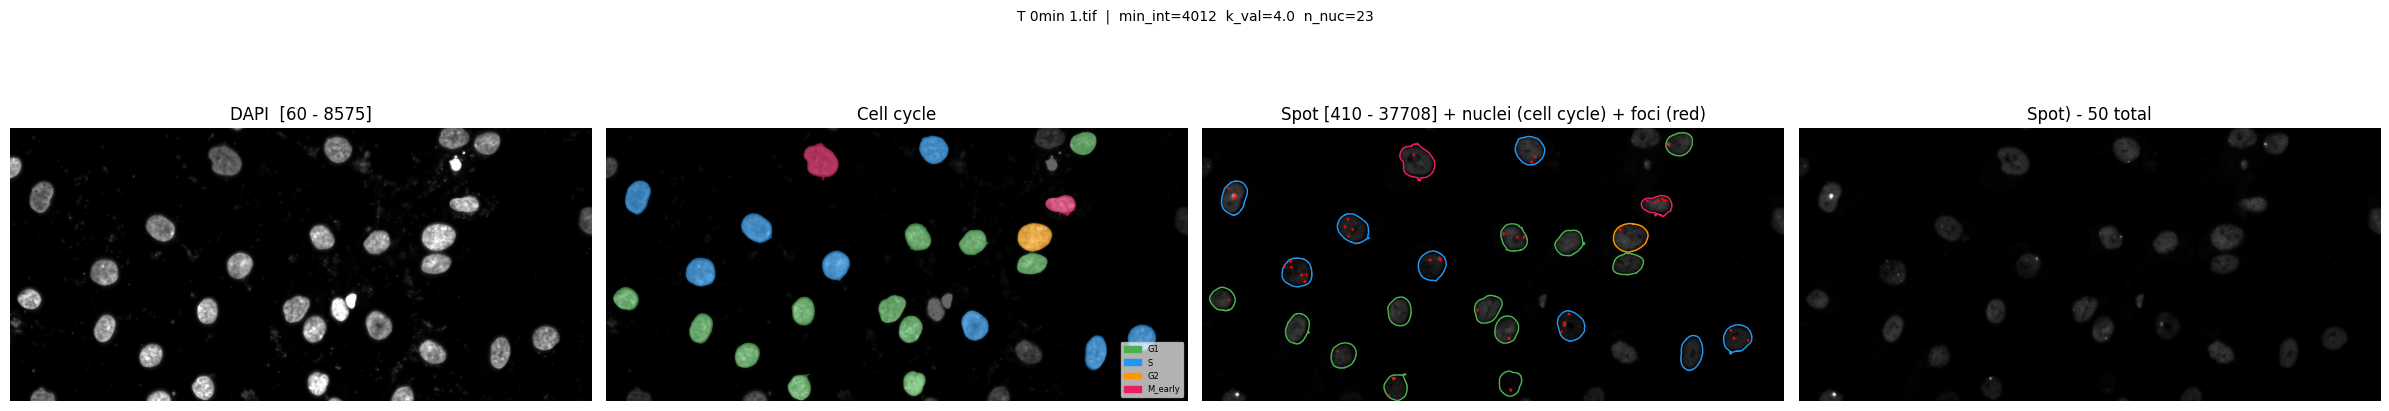

If this looks correct, run Cell 13 to process all images.
If not, adjust parameters in Cell 11 and re-run this cell.


In [42]:
# ── Load first image ──────────────────────────────────────────────────────
qc_path = tif_files[0]
img_raw = load_volume(qc_path)
meta    = read_tiff_metadata(qc_path)

print(f'QC image   : {qc_path.name}')
print(f'Shape      : {img_raw.shape}  dtype: {img_raw.dtype}')
print(f'Pixel size : {meta["dxy"]:.4f} um/px  [{meta["dxy_source"]}]')
print()

# ── Assign channels ───────────────────────────────────────────────────────
DC = params['dapi_channel']
SC = params['spot_channel']
if img_raw.ndim == 2:
    dapi_img = img_raw.copy(); spot_img = img_raw.copy()
elif img_raw.ndim == 3 and img_raw.shape[0] <= 4:  # (C, Y, X)
    dapi_img = img_raw[DC]; spot_img = img_raw[SC]
elif img_raw.ndim == 3:                             # (Z, Y, X)
    dapi_img = img_raw; spot_img = img_raw
else:                                               # (C, Z, Y, X)
    dapi_img = img_raw[DC]; spot_img = img_raw[SC]

# 2D projections for display and processing
dapi_2d = dapi_img.max(axis=0) if dapi_img.ndim == 3 else dapi_img  # numpy
spot_2d = spot_img.max(axis=0) if spot_img.ndim == 3 else spot_img  # numpy

# ── Segment nuclei ────────────────────────────────────────────────────────
label_2d = segment_nuclei_2d(
    dapi_2d,
    nuc_rad  =params['nuc_rad'],
    max_p2a  =params['max_p2a'],
    th_factor=params['nuc_th']
)
label_nuc = (np.stack([label_2d]*dapi_img.shape[0], axis=0)
             if dapi_img.ndim == 3 else label_2d)

# ── Cell cycle classification ─────────────────────────────────────────────
cc_df = classify_cell_cycle(label_2d, dapi_2d, dxy=meta['dxy'])

# ── Auto-tune display and detection parameters ────────────────────────────
suggested = auto_tune_params(dapi_2d, spot_2d, label_2d, n_sigma=5)
params.update(suggested)
print()

# ── Optional manual overrides (uncomment to override auto-tune) ───────────
# params['min_int']          = 3000
# params['dapi_min_stretch'] = 500
# params['dapi_max_stretch'] = 10000
# params['spot_min_stretch'] = 500
# params['spot_max_stretch'] = 28000

    
# ── Detect foci ───────────────────────────────────────────────────────────
foci_label, _, foci_rows = detect_foci(
    spot_img=spot_img, label_nuc=label_nuc,
    k_val        =params['k_val'],
    min_int      =params['min_int'],
    min_size     =params['min_size'],
    max_foci_size=params['max_foci_size'],
    bg_sigma     =params['bg_sigma'],
    do_z_conv    =params['do_z_conv'],
    verbose      =True
)
foci_2d = foci_label.max(axis=0) if foci_label.ndim == 3 else foci_label
print(f'\nTotal foci: {len(foci_rows)} across {label_2d.max()} nuclei')
print()

# ── QC plot — 4 panels ────────────────────────────────────────────────────
# Panel 1: DAPI
# Panel 2: Cell cycle overlay — SAME DAPI stretch as panel 1
# Panel 3: SPOT with nucleus contours colored by cell cycle + red foci
# Panel 4: SPOT with red foci contours only (clean)
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Cell cycle colors — used in all output images
phase_colors = {
    'G1':      '#4CAF50',
    'S':       '#2196F3',
    'G2':      '#FF9800',
    'M_early': '#E91E63',
    'M_late':  '#9C27B0',
    'unknown': '#9E9E9E',
}
nuc_phase = dict(zip(cc_df['nuc_id'], cc_df['cell_cycle']))

# Display stretch
vmin_d = params['dapi_min_stretch']   # same for panels 1 and 2
vmax_d = params['dapi_max_stretch']   # same for panels 1 and 2
vmin_s = params['spot_min_stretch']   # same for panels 3 and 4
vmax_s = params['spot_max_stretch']   # same for panels 3 and 4

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Panel 1: DAPI
axes[0].imshow(dapi_2d, cmap='gray', vmin=vmin_d, vmax=vmax_d)
axes[0].set_title(f'DAPI  [{vmin_d} - {vmax_d}]')
axes[0].axis('off')

# Panel 2: Cell cycle — DAPI underneath with EXACTLY the same stretch
cc_overlay = np.zeros((*label_2d.shape, 3), dtype=np.float32)
for nid, phase in nuc_phase.items():
    color = mcolors.to_rgb(phase_colors.get(phase, '#9E9E9E'))
    cc_overlay[label_2d == nid] = color
axes[1].imshow(dapi_2d, cmap='gray', vmin=vmin_d, vmax=vmax_d)  # same stretch
axes[1].imshow(cc_overlay, alpha=0.6)
patches = [mpatches.Patch(color=v, label=k) for k, v in phase_colors.items()
           if k in cc_df['cell_cycle'].values]
axes[1].legend(handles=patches, loc='lower right', fontsize=6, framealpha=0.7)
axes[1].set_title('Cell cycle')
axes[1].axis('off')

# Panel 3: SPOT + nucleus contours colored by cell cycle + red foci
axes[2].imshow(spot_2d, cmap='gray', vmin=vmin_s, vmax=vmax_s)
for nid, phase in nuc_phase.items():
    color = phase_colors.get(phase, '#9E9E9E')
    axes[2].contour((label_2d == nid).astype(float),
                    levels=[0.5], colors=[color], linewidths=1.0)
if foci_2d.max() > 0:
    axes[2].contour((foci_2d > 0).astype(float),
                    levels=[0.5], colors=['red'], linewidths=0.8)
axes[2].set_title(f'Spot [{vmin_s} - {vmax_s}] + nuclei (cell cycle) + foci (red)')
axes[2].axis('off')

# Panel 4: SPOT 
axes[3].imshow(spot_2d, cmap='gray', vmin=vmin_s, vmax=vmax_s)
axes[3].set_title(f'Spot) - {len(foci_rows)} total')
axes[3].axis('off')

plt.suptitle(
    f'{qc_path.name}  |  min_int={params["min_int"]}  '
    f'k_val={params["k_val"]}  n_nuc={label_2d.max()}',
    fontsize=10
)
plt.tight_layout()
plt.show()

print('If this looks correct, run Cell 13 to process all images.')
print('If not, adjust parameters in Cell 11 and re-run this cell.')


## CELL 13 — Batch: process all TIFFs
Processes every TIFF found in .
Appends all results to a single  and .

In [47]:
from tqdm import tqdm

nuc_fh  = None
foci_fh = None

# ── Output location ────────────────────────────────────────────────────────
# Where to save results (nuc_summary, foci_summary, per-nucleus JPEGs)
# Default: ~/Documents/output on local, /content/output on Colab
# Change this to any path you prefer

if IS_COLAB:
    OUTPUT_ROOT = Path('/content/output') / DATA_ROOT.name
else:
    OUTPUT_ROOT = Path.home() / 'Documents' / 'CostesLab_output' / DATA_ROOT.name

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Output root  : {OUTPUT_ROOT}')

for i, tif_path in enumerate(tqdm(tif_files, desc="Processing")):
    try:
        # Load
        img_raw = load_volume(tif_path)
        meta    = read_tiff_metadata(tif_path)

        # Assign channels
        DC = params["dapi_channel"]
        SC = params["spot_channel"]
        if img_raw.ndim == 2:
            dapi_img = img_raw.copy(); spot_img = img_raw.copy()
        elif img_raw.ndim == 3 and img_raw.shape[0] <= 4:
            dapi_img = img_raw[DC]; spot_img = img_raw[SC]
        elif img_raw.ndim == 3:
            dapi_img = img_raw; spot_img = img_raw
        else:
            dapi_img = img_raw[DC]; spot_img = img_raw[SC]

        # Segment nuclei
        dapi_2d  = dapi_img.max(axis=0) if dapi_img.ndim == 3 else dapi_img
        label_2d = segment_nuclei_2d(
            dapi_2d,
            nuc_rad  =params["nuc_rad"],
            max_p2a  =params["max_p2a"],
            th_factor=params["nuc_th"]
        )
        label_nuc = (np.stack([label_2d]*dapi_img.shape[0], axis=0)
                     if dapi_img.ndim == 3 else label_2d)

        # Cell cycle classification
        cc_df = classify_cell_cycle(label_2d, dapi_2d, dxy=meta["dxy"])

        # Detect foci
        spot_2d = spot_img.max(axis=0) if spot_img.ndim == 3 else spot_img
        foci_label, _, foci_rows = detect_foci(
            spot_img=spot_img, label_nuc=label_nuc,
            k_val=params["k_val"], min_int=params["min_int"],
            min_size=params["min_size"], max_foci_size=params["max_foci_size"],
            bg_sigma=params["bg_sigma"], do_z_conv=params["do_z_conv"],
            verbose=False
        )
        foci_2d = foci_label.max(axis=0) if foci_label.ndim == 3 else foci_label

        # Save outputs
        nuc_fh, foci_fh = save_outputs(
            tif_path    =tif_path,
            dapi_img    =dapi_2d,
            spot_img    =spot_2d,
            label_nuc   =label_2d,
            foci_label  =foci_2d,
            foci_rows   =foci_rows,
            cc_df       =cc_df,
            meta        =meta,
            output_dir  =OUTPUT_ROOT,
            spot_min    =params["spot_min_stretch"],
            spot_max    =params["spot_max_stretch"],
            nuc_sum_fh  =nuc_fh,
            foci_sum_fh =foci_fh,
            first_image =(i == 0)
        )

        print(f"  {tif_path.name}: {label_2d.max()} nuclei, {len(foci_rows)} foci")

    except Exception as e:
        import traceback
        print(f"  ERROR {tif_path.name}: {e}")
        traceback.print_exc()

# Close output files
if nuc_fh:  nuc_fh.close()
if foci_fh: foci_fh.close()

print(f"\nBatch complete.")
print(f"Results saved to: {OUTPUT_ROOT}")

Output root  : /home/syc63/Documents/CostesLab_output/human_blood_53bp1


Processing:   0%|                                                                                | 0/12 [00:00<?, ?it/s]

Segmented  23 nuclei kept
Rejected   863 by size  (min=1508px, max=50265px)
Rejected   5 by shape (P2A > 1.5)
Cell cycle distribution:
cell_cycle
G1         12
S           8
M_early     2
G2          1
Output files: nuc_summary_26-Jun-2026.txt, foci_summary_26-Jun-2026.txt


Processing:   8%|██████                                                                  | 1/12 [00:02<00:24,  2.23s/it]

  T 0min 1.tif: 23 nuclei, 50 foci
Segmented  34 nuclei kept
Rejected   636 by size  (min=1508px, max=50265px)
Rejected   3 by shape (P2A > 1.5)
Cell cycle distribution:
cell_cycle
G2         17
S          11
M_late      4
M_early     2
Sister pairs identified: 2


...

  T 30min 2.tif: 19 nuclei, 332 foci
Segmented  23 nuclei kept
Rejected   879 by size  (min=1508px, max=50265px)
Rejected   2 by shape (P2A > 1.5)
Cell cycle distribution:
cell_cycle
G1         9
S          8
G2         4
M_early    2


Processing:  92%|█████████████████████████████████████████████████████████████████      | 11/12 [00:28<00:02,  2.40s/it]

  T 60min 1.tif: 23 nuclei, 367 foci
Segmented  46 nuclei kept
Rejected   236 by size  (min=1508px, max=50265px)
Rejected   4 by shape (P2A > 1.5)
Cell cycle distribution:
cell_cycle
S          27
G1         10
M_late      4
G2          3
M_early     2
Sister pairs identified: 2


Processing: 100%|███████████████████████████████████████████████████████████████████████| 12/12 [00:31<00:00,  2.61s/it]

  T 60min 2.tif: 46 nuclei, 593 foci

Batch complete.
Results saved to: /home/syc63/Documents/CostesLab_output/human_blood_53bp1
